<a href="https://colab.research.google.com/github/pranavbalakrishna16-collab/minor-project/blob/main/Logistic_Regression_on_loan_approval(minor_project3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [ ]:
#uploading loan approval dataset
from google.colab import files

uploaded = files.upload()
csv_file = next(iter(uploaded))
df = pd.read_csv(csv_file)

print('Shape:', df.shape)
df.head()

Saving loan_approval_dataset.csv to loan_approval_dataset (1).csv
Shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
numerical_columns= df.select_dtypes(include='number')
numerical_columns

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,1,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,2,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,4,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000
...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,1000000,2300000,12,317,2800000,500000,3300000,800000
4265,4266,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000
4266,4267,2,6500000,23900000,18,457,1200000,12400000,18100000,7300000
4267,4268,1,4100000,12800000,8,780,8200000,700000,14100000,5800000


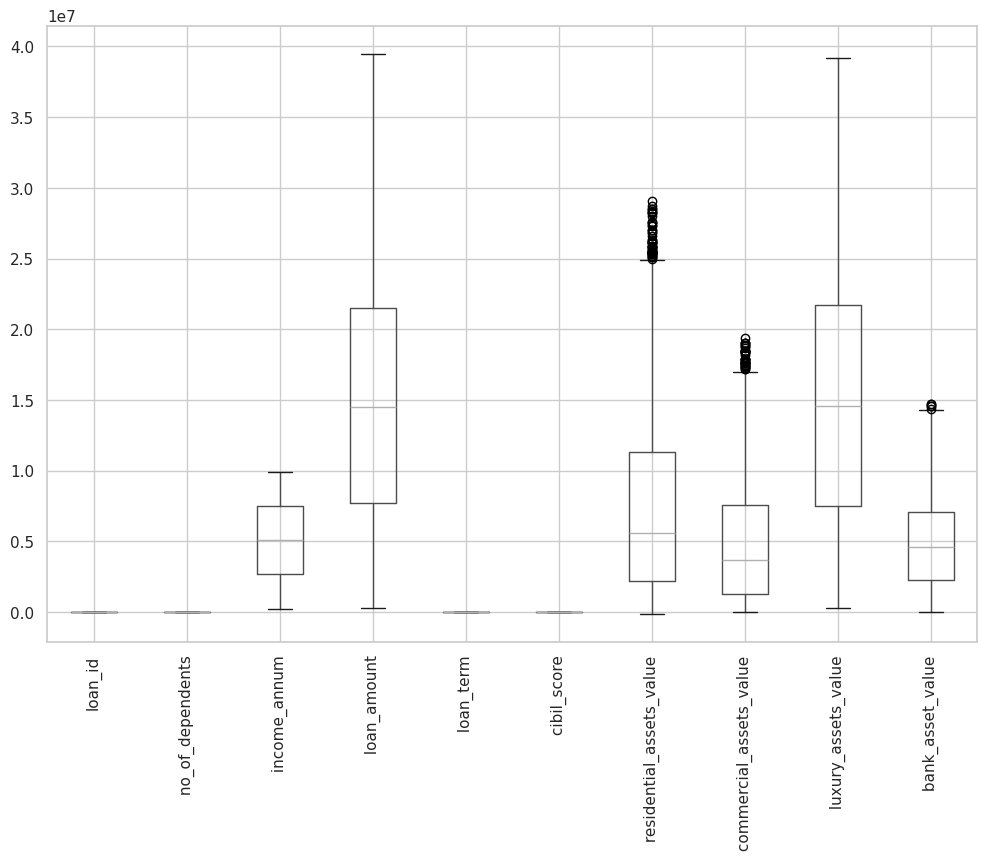

In [ ]:
numerical_columns.boxplot(figsize=(12,8))
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Strip leading/trailing whitespaces from column names to fix the KeyError
df.columns = df.columns.str.strip()

# Univariate analysis
print(df['loan_status'].value_counts())

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

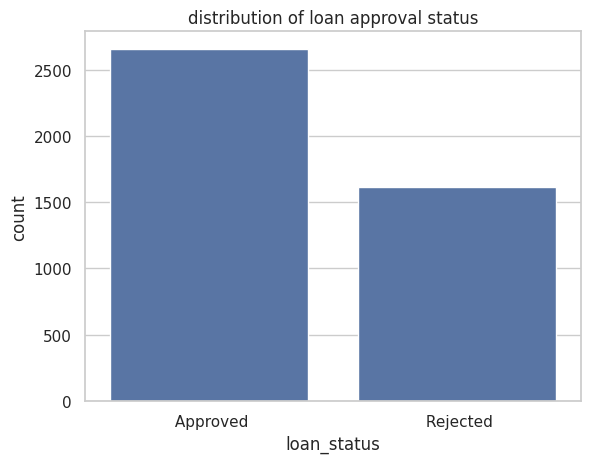

In [ ]:
sns.countplot(data=df, x='loan_status')
plt.title("distribution of loan approval status")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

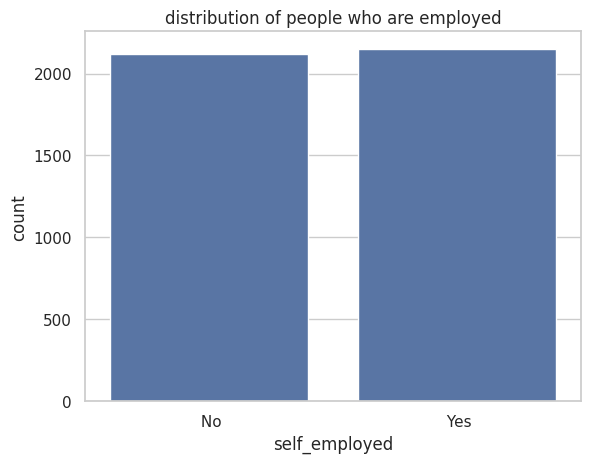

In [ ]:
sns.countplot(data=df, x= "self_employed")
plt.title("distribution of people who are employed")
plt.show

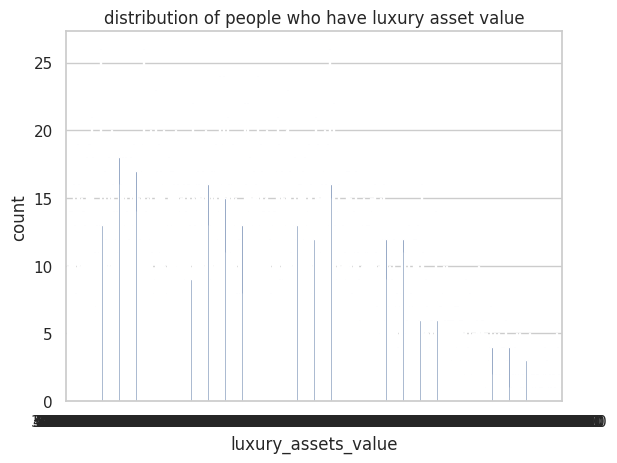

In [55]:
sns.countplot(data=df, x= "luxury_assets_value")
plt.title("distribution of people who have luxury asset value")
plt.show()

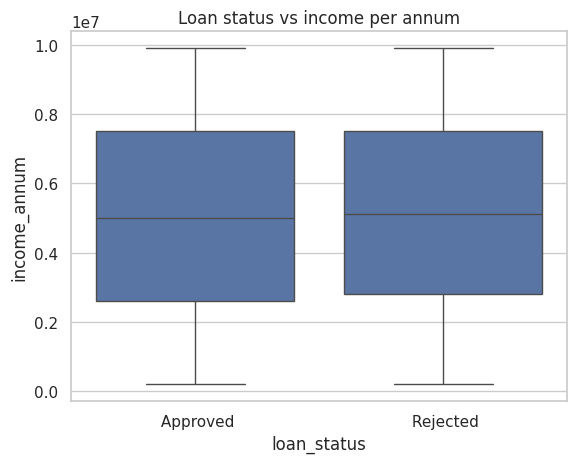

In [29]:
#Bivariate analysis
sns.boxplot(data=df, x="loan_status",y="income_annum")
plt.title("Loan status vs income per annum")
plt.show()

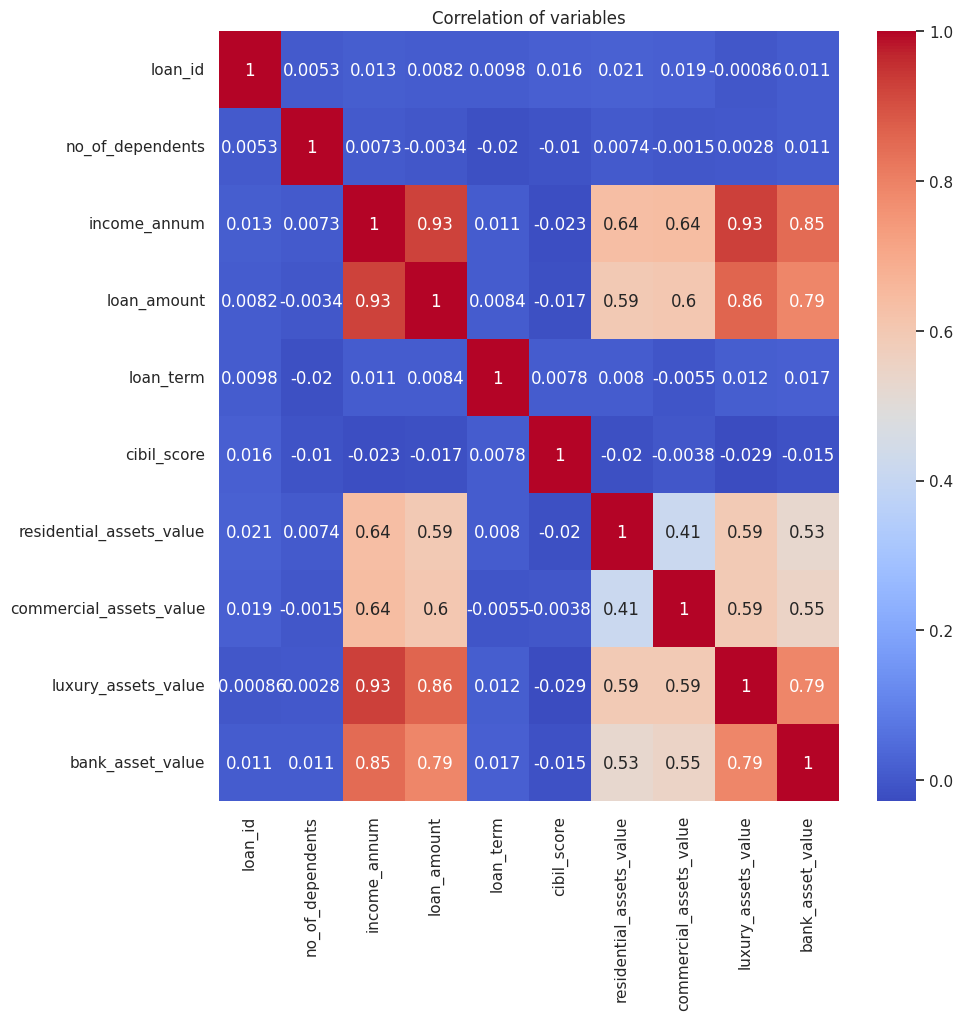

In [32]:
#multivariate analysis
corr = df.corr(numeric_only = True)
plt.figure(figsize= (10,10))
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.title("Correlation of variables")
plt.show()

In [41]:
numeric_df = df.select_dtypes(include=['int64','float64']).columns
numeric_df

Index(['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount',
       'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

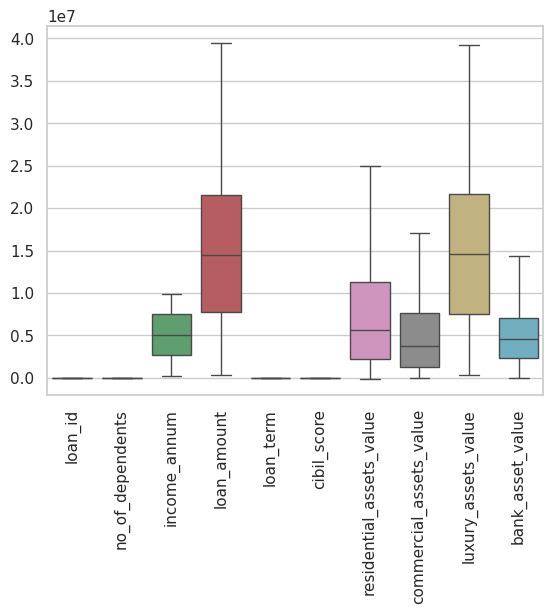

In [57]:
# detection of outliers
sns.boxplot(data= df[numeric_df])
plt.xticks(rotation=90)
plt.show()

In [43]:
#treating outliers
outlier_columns=[
    'loan_id',
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value',
]

In [45]:
#apply IQR
for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    #cap values
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

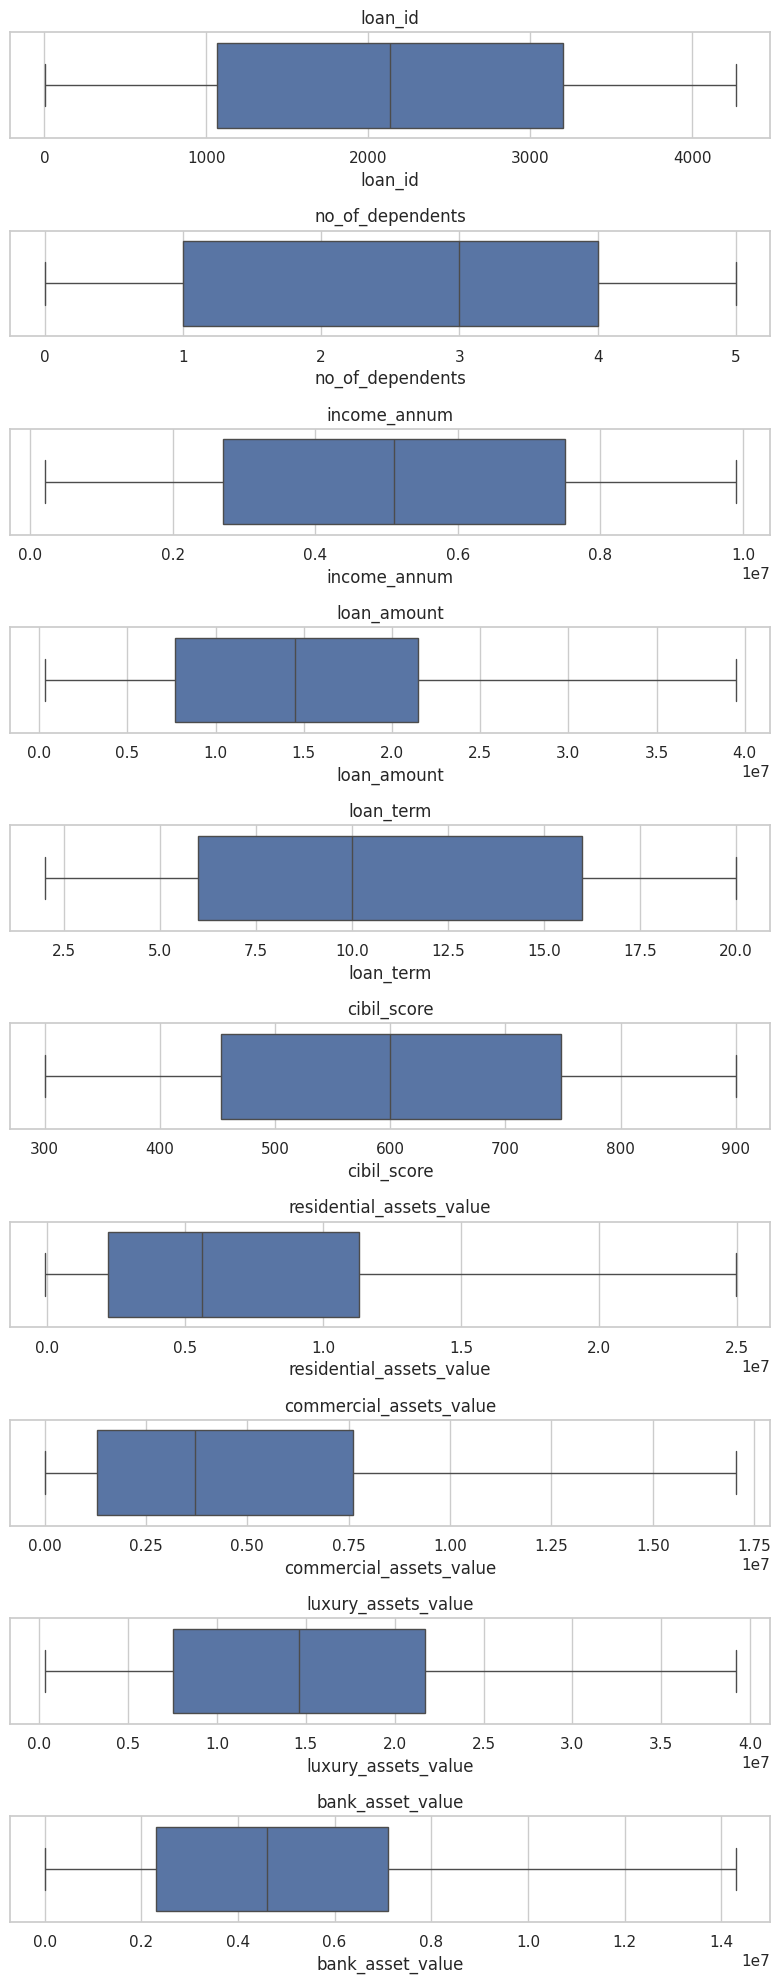

In [48]:
fig, axes = plt.subplots(len(outlier_columns),1,figsize=(8,20))
for i, column in enumerate(outlier_columns):
    sns.boxplot(x=df[column], ax=axes[i])
    axes[i].set_title(column)
plt.tight_layout()
plt.show()

In [49]:
X= df.drop ('loan_status', axis=1)
y= df['loan_status']

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [52]:
print (X_train.shape)
print (X_test.shape)
print (y_train.shape)
print (y_test.shape)

(3415, 12)
(854, 12)
(3415,)
(854,)


In [61]:

from imblearn.over_sampling import SMOTE


# 2. Encode categorical columns using dummy variables (drop_first=True to avoid multi-collinearity)
X_encoded = pd.get_dummies(df.drop('loan_status', axis=1), columns=['education', 'self_employed'], drop_first=True, dtype=int)
y_encoded = df['loan_status']

# 3. Re-split the encoded dataset
X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)

# 4. Apply SMOTE to the encoded training data
print("Before SMOTE:\n", y_train_enc.value_counts())
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_enc, y_train_enc)

print("\nAfter SMOTE:\n", y_train_resampled.value_counts())

Before SMOTE:
 loan_status
Approved    2120
Rejected    1295
Name: count, dtype: int64

After SMOTE:
 loan_status
Approved    2120
Rejected    2120
Name: count, dtype: int64


In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test_enc)

In [72]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_scaled, y_train_resampled)

LogisticRegression()

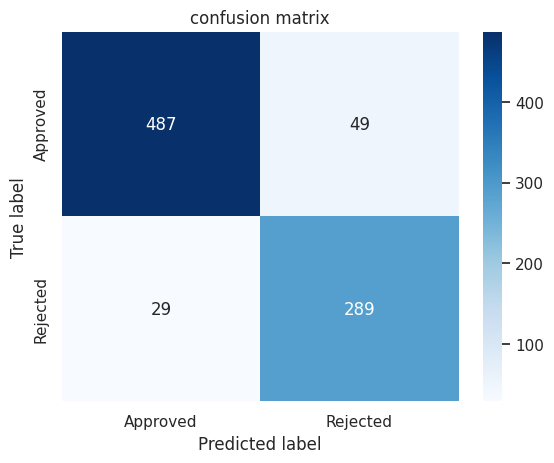

accuracy 0.9086651053864169
precision 0.9437984496124031
recall 0.9085820895522388
f1 score 0.9258555133079848
class_report:
               precision    recall  f1-score   support

    Approved       0.94      0.91      0.93       536
    Rejected       0.86      0.91      0.88       318

    accuracy                           0.91       854
   macro avg       0.90      0.91      0.90       854
weighted avg       0.91      0.91      0.91       854



In [78]:
#Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt


y_pred = model.predict(X_test_scaled)

# striping the strings
# I utilised the AI (gemini) agent for this particular code snippet as my dataset was a little complex.
y_test_cleaned = y_test_enc.str.strip() if hasattr(y_test_enc, 'str') else [str(x).strip() for x in y_test_enc]
y_pred_cleaned = [str(x).strip() for x in y_pred]

accuracy = accuracy_score(y_test_cleaned, y_pred_cleaned)
precision = precision_score(y_test_cleaned, y_pred_cleaned, pos_label='Approved')
recall = recall_score(y_test_cleaned, y_pred_cleaned, pos_label='Approved')
f1 = f1_score(y_test_cleaned, y_pred_cleaned, pos_label='Approved')
confusion_mat = confusion_matrix(y_test_cleaned, y_pred_cleaned, labels=['Approved', 'Rejected'])
class_report = classification_report(y_test_cleaned, y_pred_cleaned)
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues", xticklabels=['Approved', 'Rejected'], yticklabels=['Approved', 'Rejected'])
plt.title("confusion matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()
print("accuracy", accuracy)
print("precision", precision)
print("recall", recall)
print("f1 score", f1)
print('class_report:\n', class_report)